# OpenFold3 input embeddings

Before OpenFold3 builds a structure, its first module, the input embedder, converts the sequence into a
numerical representation of every residue. The complete model needs a large GPU, whereas the input
embedder is small. This notebook isolates the input embedder of the trained OpenFold3, runs it on its own,
confirms that it reproduces the output of the full model, computes the representations for every protein
in the dataset and examines what they encode. The representations are not used in notebooks 00–05; they
are provided for further analysis.

**Environment:** Google Colab with a T4 GPU (Runtime → Change runtime type). Run the cells in order; if
Colab asks to restart the session after the installation cell, restart and continue from section 1.
Results are written to Google Drive (`MyDrive/thesis_of3/`). A full run takes about 1–1.5 hours. To
repeat only the model-free part (section 7 and the end of section 8, a few minutes), run sections 0 and 1
and the helper cell, then continue from section 7.  
**Output:** the input-embedder weights, the embeddings of every protein and
`summary_of3_input_embeddings.json`, on Drive.

## 0. Install

Version **0.4.3** on purpose: its default weights (`of3-p2-155k`) were trained on PDB entries
up to 2021 — the same model family as the OpenFold3 on NVIDIA NIM that produced the predictions
(NIM model card: training structures deposited before 2021-09-30). Version 0.5.0 would install the
OpenBind-0 weights (2025 cutoff), a different model.

In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
!pip install -q "openfold3==0.4.3"

name, memory.total [MiB]
Tesla T4, 15360 MiB
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.9/149.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.6/273.6 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Drive, versions, weights

`setup_openfold --non-interactive` downloads the default weights and the chemical component
dictionary (used to build each residue's reference conformer) into `~/.openfold3/`.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import importlib.metadata as md
import os
from pathlib import Path

import torch

WORK = Path("/content/drive/MyDrive/thesis_of3")
WORK.mkdir(parents=True, exist_ok=True)
os.chdir("/content")

print("openfold3", md.version("openfold3"), "| torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
assert md.version("openfold3") == "0.4.3", "wrong OpenFold3 version"
assert torch.cuda.is_available(), "no GPU: Runtime -> Change runtime type -> T4 GPU"

Mounted at /content/drive
openfold3 0.4.3 | torch 2.11.0+cu130 | CUDA: True


In [3]:
!setup_openfold --non-interactive
CKPT = Path.home() / ".openfold3" / "of3-p2-155k.pt"
assert CKPT.exists(), sorted(p.name for p in (Path.home() / ".openfold3").iterdir())
print(CKPT, f"{CKPT.stat().st_size / 1e9:.2f} GB")

Parameters directory set to: /root/.openfold3
Starting parameter download...
of3-p2-155k.pt: 100% 2.29G/2.29G [00:31<00:00, 72.5MB/s]
Download complete.
Download completed successfully.
Starting Biotite CCD setup...
components.bcif: 100% 63.4M/63.4M [00:02<00:00, 21.6MB/s]
Download complete.
Skipping integration tests.
Setup configuration saved to /root/.openfold3/setup_config.json
/root/.openfold3/of3-p2-155k.pt 2.29 GB


## Helper functions

All helpers in one cell (tested offline against the OpenFold3 0.4.3 source).

In [4]:
"""Helper functions for notebook 06 (OpenFold3 input embeddings)."""

import json
import os
import time
from pathlib import Path

import numpy as np
import requests
import torch

from openfold3.core.model.feature_embedders.input_embedders import InputEmbedderAllAtom

OUTPUT_NAMES = ("s_input", "s_init", "z_init")


# ── inputs ──────────────────────────────────────────────────────────────────


def fetch_uniprot_sequence(accession: str) -> str:
    """Canonical sequence from UniProt (the same sequence given to AF2 and to OF3 on NIM)."""
    r = requests.get(f"https://rest.uniprot.org/uniprotkb/{accession}.fasta", timeout=30)
    r.raise_for_status()
    return "".join(line.strip() for line in r.text.splitlines() if not line.startswith(">"))


def write_query_json(path, queries: dict) -> str:
    """queries = {name: sequence}; one single-chain protein query each (OpenFold3 query format)."""
    content = {
        "queries": {
            name: {"chains": [{"molecule_type": "protein", "chain_ids": ["A"], "sequence": seq}]}
            for name, seq in queries.items()
        }
    }
    Path(path).write_text(json.dumps(content, indent=2))
    return str(path)


def write_runner_yaml(path, seeds, write_latent_outputs: bool = True) -> str:
    """
    Runner settings: model seeds, the trunk embeddings (si_trunk, zij_trunk) written to disk, and
    NO data-loader worker processes.  OpenFold3's default is 10 workers; Colab has 2 CPUs and about
    12 GB of RAM, and every worker is a separate process that loads its own copy of the data
    pipeline, which crashed the session ("used all available RAM").  A single query needs no workers.
    """
    seeds_text = ", ".join(str(int(s)) for s in seeds)
    text = (
        "experiment_settings:\n"
        f"  seeds: [{seeds_text}]\n"
        "output_writer_settings:\n"
        f"  write_latent_outputs: {'true' if write_latent_outputs else 'false'}\n"
        "data_module_args:\n"
        "  num_workers: 0\n"
    )
    Path(path).write_text(text)
    return str(path)


# ── capturing the input embedder inside the full model ──────────────────────


class InputEmbedderRecorder:
    """
    While active, every call of InputEmbedderAllAtom.forward (inside the full
    model) is recorded: the exact feature batch it received (tensors, on CPU),
    its keyword arguments and its three outputs (s_input, s_init, z_init).
    """

    def __init__(self):
        self.records = []
        self._original = None

    def __enter__(self):
        self._original = InputEmbedderAllAtom.forward
        original, records = self._original, self.records

        def recording_forward(module, batch, *args, **kwargs):
            outputs = original(module, batch, *args, **kwargs)
            records.append(
                {
                    "query_id": batch.get("query_id"),
                    "seed": batch.get("seed"),
                    "batch": {k: v.detach().cpu() for k, v in batch.items() if torch.is_tensor(v)},
                    "kwargs": {k: v for k, v in kwargs.items() if isinstance(v, (bool, int, float))},
                    "outputs": {n: t.detach().float().cpu() for n, t in zip(OUTPUT_NAMES, outputs)},
                }
            )
            return outputs

        InputEmbedderAllAtom.forward = recording_forward
        return self

    def __exit__(self, *exc):
        InputEmbedderAllAtom.forward = self._original
        return False


def run_predict(query_json, runner_yaml, output_dir, num_diffusion_samples: int = 1,
                checkpoint_path=None) -> None:
    """
    `run_openfold predict`, MSA-free and without templates, IN THIS PROCESS
    (so that InputEmbedderRecorder sees the model; a `!run_openfold` shell
    command would run in another process).
    """
    from openfold3.run_openfold import cli

    args = [
        "predict",
        "--query-json", str(query_json),
        "--runner-yaml", str(runner_yaml),
        "--use-msa-server", "False",
        "--use-templates", "False",
        "--num-diffusion-samples", str(num_diffusion_samples),
        "--output-dir", str(output_dir),
    ]
    if checkpoint_path:
        args += ["--inference-ckpt-path", str(checkpoint_path)]
    cli.main(args=args, standalone_mode=False)
    # Free what the run left behind: every run builds the whole model (~370 M parameters) in CPU RAM,
    # and Colab's free tier has only ~12 GB, so several runs in one session can add up to a crash.
    import gc

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        import psutil

        print(f"[RAM in use after this run: {psutil.Process().memory_info().rss / 1e9:.1f} GB "
              f"of {psutil.virtual_memory().total / 1e9:.1f} GB]")
    except ImportError:
        pass


def first_value(x):
    """batch['query_id'] / batch['seed'] are lists (batch size 1): their single value."""
    if isinstance(x, (list, tuple)) and len(x) == 1:
        return x[0]
    if torch.is_tensor(x) and x.numel() == 1:
        return x.item()
    return x


# ── loading only the input-embedding weights ────────────────────────────────


def model_params_from_checkpoint(ckpt: dict):
    """
    The model weights inside an OpenFold3 checkpoint, chosen exactly as
    OpenFold3 does for inference (get_state_dict_from_checkpoint with
    init_from_ema_weights=True): a file without "state_dict"/"module" IS the
    parameter dict; otherwise the EMA parameters are used.
    Returns (params, description).
    """
    if "module" not in ckpt and "state_dict" not in ckpt:
        return ckpt, "plain parameter file"
    if isinstance(ckpt.get("ema"), dict) and "params" in ckpt["ema"]:
        return ckpt["ema"]["params"], "training checkpoint, EMA parameters"
    return ckpt.get("state_dict") or ckpt["module"], "training checkpoint without EMA"


def extract_input_embedder_state(params: dict, prefix: str = "input_embedder.") -> dict:
    """Only the input-embedder tensors, with the prefix (and a leading 'model.') removed."""
    out = {}
    for key, value in params.items():
        name = key[len("model."):] if key.startswith("model.") else key
        if name.startswith(prefix) and torch.is_tensor(value):
            out[name[len(prefix):]] = value
    return out


def build_input_embedder(state_dict: dict, model_config) -> InputEmbedderAllAtom:
    """InputEmbedderAllAtom with exactly these weights (strict: every tensor must match)."""
    module = InputEmbedderAllAtom(**model_config.architecture.input_embedder)
    module.load_state_dict(state_dict, strict=True)
    return module.eval()


def run_embedder(module, record: dict, device: str = "cpu"):
    """Run the standalone module on a recorded batch. Returns ({name: tensor}, seconds)."""
    module = module.to(device)
    batch = {k: v.to(device) for k, v in record["batch"].items()}
    kwargs = dict(record.get("kwargs") or {})
    kwargs.setdefault("use_high_precision_attention", True)
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        outputs = module(batch=batch, **kwargs)
    if device == "cuda":
        torch.cuda.synchronize()
    seconds = time.perf_counter() - start
    return {n: t.detach().float().cpu() for n, t in zip(OUTPUT_NAMES, outputs)}, seconds


def max_abs_diff(a: dict, b: dict) -> dict:
    """Largest absolute difference per output (same shapes required)."""
    return {n: float((a[n] - b[n]).abs().max()) for n in OUTPUT_NAMES}


# ── analysis of the representations ─────────────────────────────────────────


def tokens(t: torch.Tensor) -> np.ndarray:
    """Per-residue representation [1, N, C] (or [N, C]) -> numpy [N, C]."""
    x = t.detach().float().cpu().numpy()
    while x.ndim > 2 and x.shape[0] == 1:
        x = x[0]
    if x.ndim != 2:
        raise ValueError(f"expected a per-residue tensor [N, C], got shape {x.shape}")
    return x


def cosine_matrix(x: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    y = x / norm
    return y @ y.T


def relative_difference(records: list, name: str) -> float:
    """Mean over pairs of seeds of |a - b| / |a| for one output (any shape)."""
    xs = [r["outputs"][name].float() for r in records]
    values = [
        float((xs[i] - xs[j]).norm() / xs[i].norm())
        for i in range(len(xs))
        for j in range(i + 1, len(xs))
    ]
    return float(np.mean(values)) if values else float("nan")


def seed_spread(records: list, name: str = "s_init") -> dict:
    """
    How much the per-residue embedding (s_input or s_init) of the SAME sequence
    changes between seeds, against how different the embeddings of different
    residues are.  (The reference conformer of every residue is randomly
    rotated when the features are built: AF3 Algorithm 19.)
    """
    xs = [tokens(r["outputs"][name]) for r in records]
    per_token_cos = []
    for i in range(len(xs)):
        for j in range(i + 1, len(xs)):
            a, b = xs[i], xs[j]
            cos = (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))
            per_token_cos.append(cos.mean())
    first = xs[0]
    between = cosine_matrix(first)[np.triu_indices(len(first), k=1)]
    return {
        "n_seeds": len(xs),
        "same_residue_cosine_between_seeds": float(np.mean(per_token_cos)) if per_token_cos else None,
        "relative_difference_between_seeds": relative_difference(records, name),
        "different_residues_cosine": float(between.mean()) if len(between) else None,
    }


def residue_type_agreement(x: np.ndarray, letters: str) -> float:
    """Fraction of tokens whose nearest other token (cosine) is the same amino acid."""
    sim = cosine_matrix(x)
    np.fill_diagonal(sim, -np.inf)
    nearest = sim.argmax(axis=1)
    letters = np.array(list(letters))
    return float((letters[nearest] == letters).mean())


def ca_coordinates(cif_path: str) -> np.ndarray:
    """Cα coordinates of chain A of a predicted structure (biotite, an OpenFold3 dependency)."""
    import biotite.structure as struc
    from biotite.structure.io import pdbx

    atoms = pdbx.get_structure(pdbx.CIFFile.read(str(cif_path)), model=1)
    ca = atoms[(atoms.atom_name == "CA") & struc.filter_amino_acids(atoms)]
    return ca.coord


def similarity_vs_distance(x: np.ndarray, ca: np.ndarray, min_separation: int = 6) -> float:
    """
    Spearman correlation between token-token cosine similarity and minus the
    Cα-Cα distance, over residue pairs at least `min_separation` apart in
    sequence: does the representation know which residues are close in space?
    """
    from scipy.stats import spearmanr

    n = min(len(x), len(ca))
    i, j = np.triu_indices(n, k=min_separation)
    sim = cosine_matrix(x[:n])[i, j]
    dist = np.linalg.norm(ca[:n][i] - ca[:n][j], axis=1)
    return float(spearmanr(sim, -dist).correlation)


def sha256(path: str, chunk: int = 1 << 24) -> str:
    import hashlib

    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


# ── without the model: OpenFold3's features from its data pipeline alone ──


def feature_batches(query_json, runner_yaml, placeholder_ckpt, output_dir="out_features"):
    """
    The feature batches OpenFold3's inference pipeline builds for a query file (MSA-free, no
    templates) WITHOUT building the model or reading the checkpoint: the data module that
    `run_openfold predict` uses, iterated on its own.  The configuration insists on a checkpoint
    path, so `placeholder_ckpt` must be an existing file; it is never opened.
    """
    from openfold3.core.config import config_utils
    from openfold3.entry_points.experiment_runner import InferenceExperimentRunner
    from openfold3.entry_points.validator import InferenceExperimentConfig
    from openfold3.projects.of3_all_atom.config.inference_query_format import InferenceQuerySet

    config = InferenceExperimentConfig(
        inference_ckpt_path=Path(placeholder_ckpt), **config_utils.load_yaml(runner_yaml)
    )
    runner = InferenceExperimentRunner(config, use_msa_server=False, use_templates=False, output_dir=Path(output_dir))
    runner.inference_query_set = InferenceQuerySet.from_json(query_json)
    data = runner.lightning_data_module
    data.prepare_data()
    data.setup("predict")
    yield from data.predict_dataloader()


def seeded_feature_batches(query_json, runner_yaml, placeholder_ckpt, seed: int = 42):
    """
    feature_batches() with the random state fixed first.  Each residue's reference conformer is
    generated by RDKit (ETKDG, its seed drawn from Python's `random`) and then randomly rotated and
    translated (torch).  OpenFold3 itself sets the seed only after the features are built (§6).
    """
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    yield from feature_batches(query_json, runner_yaml, placeholder_ckpt)


def as_record(batch: dict) -> dict:
    """A feature batch in the form run_embedder() takes: its tensors and the model's inference arguments."""
    return {
        "query_id": batch.get("query_id"),
        "batch": {k: v for k, v in batch.items() if torch.is_tensor(v)},
        "kwargs": {"inplace_safe": True, "use_high_precision_attention": True},
    }


def differing_tensors(recorded: dict, features: dict) -> list:
    """Names of the recorded feature tensors that are not identical in `features`."""
    return [k for k, v in recorded.items() if not torch.equal(v.float(), features[k].float())]


def relative_change(a: dict, b: dict) -> dict:
    """|a − b| / |b| for each output: how far two embeddings of the same sequence are apart."""
    return {n: float((a[n].float() - b[n].float()).norm() / b[n].float().norm()) for n in OUTPUT_NAMES}


def modelfree_embeddings(module, name: str, sequence: str, runner_yaml, placeholder_ckpt, seed: int = 42):
    """
    Input embeddings of one chain without the full model: a query file of its own, the random state
    fixed, OpenFold3's features, then the extracted module on the CPU.  One chain per query, so the
    result depends only on the sequence and the seed, not on the other queries of a file.
    Returns ({name: tensor}, seconds).
    """
    query = write_query_json(f"query_{name}.json", {name: sequence})
    start = time.perf_counter()
    batch = next(seeded_feature_batches(query, runner_yaml, placeholder_ckpt, seed=seed))
    out, _ = run_embedder(module, as_record(batch), device="cpu")
    return out, time.perf_counter() - start

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. OpenFold3 on Colab: MSA-free prediction of a 15-residue fragment

The fragment is residues 2–16 of thioredoxin (P0AA25, one of the proteins of the set). The prediction runs
**in this Python process** with a recorder around `InputEmbedderAllAtom.forward`, which keeps the exact
feature batch the official pipeline built and the full model's own input-embedding output (needed in §5).
`write_latent_outputs` also saves the trunk embeddings `si_trunk` [N, 384] and `zij_trunk` [N, N, 128].

In [5]:
seq_trx = fetch_uniprot_sequence("P0AA25")
FRAG = seq_trx[1:16]
print("fragment:", FRAG, len(FRAG))

write_query_json("query_frag.json", {"frag15": FRAG})
write_runner_yaml("runner_seed42.yml", seeds=[42])
with InputEmbedderRecorder() as rec_frag:
    run_predict("query_frag.json", "runner_seed42.yml", "out_frag", checkpoint_path=CKPT)

print(len(rec_frag.records), "call(s) of the input embedder recorded")
latent = torch.load("out_frag/frag15/seed_42/frag15_seed_42_latent_output.pt", map_location="cpu", weights_only=False)
print({k: tuple(v.shape) for k, v in latent.items() if torch.is_tensor(v)})
torch.save(rec_frag.records, WORK / "capture_frag15_seed42.pt")

fragment: SDKIIHLTDDSFDTD 15


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model re

Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

/usr/local/lib/python3.13/dist-packages/biotite/structure/io/pdbx/convert.py:1024: DeprecationWarning: 
`include_bonds` parameter is deprecated, intra-residue are always written, if available
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.13/dist-packages/biotite/structure/io/pdbx/convert.py:1024: DeprecationWarning: 
`include_bonds` parameter is deprecated, intra-residue are always written, if available
  warnings.warn(

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

==================================================
    PREDICTION SUMMARY (COMPLETE)    
==================================================
Total Queries Processed: 1
  - Successful Queries:  1
  - Failed Queries:      0
==================================================

Removing empty log directory...
[RAM in use after this run: 7.6 GB of 13.6 GB]
1 call(s) of the input embedder recorded
{'si_trunk': (1, 15, 384), 'zij_trunk': (1, 15, 15, 128), 'atom_positions_predicted': (1, 120, 3), 'distogram_logits': (1, 15, 15, 64), 'plddt_logits': (1, 120, 50), 'experimentally_resolved_logits': (1, 120, 2), 'pae_logits': (1, 15, 15, 64), 'pde_logits': (1, 15, 15, 64)}


## 3. Where the input embedding is

`openfold3/core/model/feature_embedders/input_embedders.py`, class **`InputEmbedderAllAtom`**:
AlphaFold3 Algorithm 1 lines 1–5 = Algorithm 2 (InputFeatureEmbedder) + Algorithm 3 (RelativePositionEncoding).
It is called at the start of `OpenFold3.run_trunk` (`openfold3/projects/of3_all_atom/model.py`):
`s_input, s_init, z_init = self.input_embedder(batch)`.

* **Reads:** per-atom reference chemistry of every residue (`ref_pos`, `ref_element`, `ref_charge`,
  `ref_atom_name_chars`, `ref_space_uid`, `atom_to_token_index`, …), the residue type (`restype`), the
  MSA profile and `deletion_mean` (MSA-free: the profile is just the one-hot sequence, `deletion_mean` = 0),
  relative positions (clipped at ±32 residues) and token bonds.
* **Outputs:** `s_input` [N, 449] = atom-encoder output 384 + restype 32 + profile 32 + deletion_mean 1;
  `s_init` [N, 384] (single representation); `z_init` [N, N, 128] (pair representation).

In [6]:
import inspect
from openfold3.projects.of3_all_atom.config.model_config import model_config

ie_cfg = model_config.architecture.input_embedder
probe = InputEmbedderAllAtom(**ie_cfg)
n_ie = sum(p.numel() for p in probe.parameters())
print(inspect.getsourcefile(InputEmbedderAllAtom))
print(f"input embedder: {n_ie:,} parameters in {len(probe.state_dict())} tensors")
print("c_s_input", ie_cfg.c_s_input, "| c_s", ie_cfg.c_s, "| c_z", ie_cfg.c_z,
      "| max_relative_idx", ie_cfg.max_relative_idx)

/usr/local/lib/python3.13/dist-packages/openfold3/core/model/feature_embedders/input_embedders.py
input embedder: 1,345,568 parameters in 98 tensors
c_s_input 449 | c_s 384 | c_z 128 | max_relative_idx 32


## 4. Only the input-embedding weights

The checkpoint is read once (memory-mapped), the model weights are chosen exactly as OpenFold3 does for
inference (EMA weights in a training checkpoint), and only the 98 `input_embedder.*` tensors are kept.
`strict=True` fails loudly if a single tensor is missing or extra. The 5 MB subset is saved, so later
work never needs the full checkpoint.

In [7]:
import openfold3.entry_points.experiment_runner  # noqa: F401 -- registers OpenFold3's classes for torch.load

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False, mmap=True)
params, ckpt_format = model_params_from_checkpoint(ckpt)
n_model = sum(v.numel() for v in params.values() if torch.is_tensor(v))
sub = extract_input_embedder_state(params)
n_sub = sum(v.numel() for v in sub.values())
emb = build_input_embedder(sub, model_config)  # strict load

SUBSET = WORK / "input_embedder_p2_155k.pt"
torch.save({k: v.clone() for k, v in sub.items()}, SUBSET)
print("checkpoint:", ckpt_format)
print(f"model: {n_model:,} numbers | input embedder: {len(sub)} tensors, {n_sub:,} numbers "
      f"= {100 * n_sub / n_model:.2f}% | subset file {SUBSET.stat().st_size / 1e6:.1f} MB")
del ckpt, params

checkpoint: plain parameter file
model: 571,537,240 numbers | input embedder: 98 tensors, 1,345,568 numbers = 0.24% | subset file 5.4 MB


## 5. The extracted module computes exactly what the trained model computes

Same recorded batch, standalone module vs the full model's own output. Then the same on CPU:
this stage needs no GPU.

In [8]:
rec = rec_frag.records[0]
out_gpu, t_gpu = run_embedder(emb, rec, device="cuda")
out_cpu, t_cpu = run_embedder(emb, rec, device="cpu")
diff_gpu, diff_cpu = max_abs_diff(out_gpu, rec["outputs"]), max_abs_diff(out_cpu, rec["outputs"])
print("max |standalone - full model|  GPU:", diff_gpu)
print("max |standalone - full model|  CPU:", diff_cpu)
print(f"time: GPU {1000 * t_gpu:.1f} ms, CPU {1000 * t_cpu:.1f} ms")
assert max(diff_gpu.values()) < 1e-4, "standalone module differs from the full model"

max |standalone - full model|  GPU: {'s_input': 0.0, 's_init': 0.0, 'z_init': 0.0}
max |standalone - full model|  CPU: {'s_input': 1.9073486328125e-06, 's_init': 1.1444091796875e-05, 'z_init': 3.0517578125e-05}
time: GPU 40.6 ms, CPU 71.1 ms


## 6. Seeds

Each residue's reference atoms are randomly rotated and translated when the features are built
(AlphaFold3 Algorithm 19, `openfold3/core/data/pipelines/featurization/conformer.py`). So the
embedding may change with the seed. Five seeds of the same fragment; seed 42 is also compared with §2.

In [9]:
import pandas as pd

SEEDS = [42, 43, 44, 45, 46]
write_runner_yaml("runner_seeds.yml", seeds=SEEDS)
with InputEmbedderRecorder() as rec_seeds:
    run_predict("query_frag.json", "runner_seeds.yml", "out_frag_seeds", checkpoint_path=CKPT)

seed_ids = [first_value(r["seed"]) for r in rec_seeds.records]
print("seeds recorded:", seed_ids)
again = rec_seeds.records[seed_ids.index(42)]
print("seed 42, two runs, max diff:", max_abs_diff(again["outputs"], rec["outputs"]))
spread = {name: seed_spread(rec_seeds.records, name) for name in ("s_input", "s_init")}
spread["z_init relative difference"] = relative_difference(rec_seeds.records, "z_init")
torch.save(rec_seeds.records, WORK / "capture_frag15_5seeds.pt")
spread

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query frag15, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_

Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

/usr/local/lib/python3.13/dist-packages/biotite/structure/io/pdbx/convert.py:1024: DeprecationWarning: 
`include_bonds` parameter is deprecated, intra-residue are always written, if available
  warnings.warn(

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

==================================================
    PREDICTION SUMMARY (COMPLETE)    
==================================================
Total Queries Processed: 5
  - Successful Queries:  5
  - Failed Queries:      0
==================================================

Removing empty log directory...
[RAM in use after this run: 7.5 GB of 13.6 GB]
seeds recorded: [42, 43, 44, 45, 46]
seed 42, two runs, max diff: {'s_input': 0.46582913398742676, 's_init': 0.8640632629394531, 'z_init': 2.594390869140625}


{'s_input': {'n_seeds': 5,
  'same_residue_cosine_between_seeds': 0.9995571374893188,
  'relative_difference_between_seeds': 0.0321744279935956,
  'different_residues_cosine': 0.9251131415367126},
 's_init': {'n_seeds': 5,
  'same_residue_cosine_between_seeds': 0.9999575614929199,
  'relative_difference_between_seeds': 0.012556584272533654,
  'different_residues_cosine': 0.9704514741897583},
 'z_init relative difference': 0.008784208446741104}

**Reading.** Seed 42 run twice does not give the same embeddings (first line of the output). The
reason is in OpenFold3's inference code. Each residue's reference conformer is random: RDKit generates
it (ETKDG, with a seed drawn from Python's `random`) and it is then randomly rotated and translated
(AlphaFold3 Algorithm 19). But OpenFold3 sets the seed at the start of each prediction step (`reseed`
in `predict_step`, `openfold3/projects/of3_all_atom/runner.py`), *after* that query's features were
built. So the first query of a run gets conformers from a state no seed controls, and every later query
gets them from the state the previous query's seed left behind — here, the run "with seed 43" was
featurized from seed 42 (§7 shows this tensor by tensor).

The spread between seeds is still the right size of this randomness: the embedding of the same residue
changes by about 1–3 % between seeds (relative difference; cosine 0.9996–0.99996), far less than
different residues differ (cosine 0.93–0.97). §7 removes it by fixing the random state before the
features are built.

## 7. Without the model: OpenFold3's features, then only the input embedder

§5 ran the extracted module on a feature batch recorded inside a full prediction, so the full model was
still built. Here the features come from OpenFold3's own inference data pipeline run on its own: no model
is built and the checkpoint is never read (the configuration insists on a path; the 5 MB subset of §4
stands in). The extracted module of §4 then computes the embeddings. This section and the model-free
part of §8 run on a CPU.

The random state (Python, NumPy, torch) is fixed before the features are built. Four checks on the
fragment:

* (a) **The same features as the full pipeline.** The §6 run with seed 43 built its features from the
  state seed 42 left; the model-free features with seed 42 are compared with that batch, tensor by
  tensor. For contrast, also with the batch of §2 (the first query of its run).
* (b) **The same embeddings.** The extracted module on the model-free features against the full model's
  own input-embedding output for that batch.
* (c) **Reproducible.** Seed 42 built twice gives identical embeddings.
* (d) **The seed decides.** Seed 43 gives other reference conformers.

In [10]:
# Only when resuming in a new Colab session: run §0, §1 and the helper cell, then this cell.
# It reloads what §2, §4 and §6 saved on Drive; neither the checkpoint nor the full model is needed.
if "rec_seeds" not in globals():
    from types import SimpleNamespace

    import pandas as pd
    from openfold3.projects.of3_all_atom.config.model_config import model_config

    SUBSET = WORK / "input_embedder_p2_155k.pt"
    emb = build_input_embedder(torch.load(SUBSET), model_config)
    rec_frag = SimpleNamespace(records=torch.load(WORK / "capture_frag15_seed42.pt", weights_only=False))
    rec_seeds = SimpleNamespace(records=torch.load(WORK / "capture_frag15_5seeds.pt", weights_only=False))
    seed_ids = [first_value(r["seed"]) for r in rec_seeds.records]
    write_query_json("query_frag.json", {"frag15": fetch_uniprot_sequence("P0AA25")[1:16]})
    write_runner_yaml("runner_seed42.yml", seeds=[42])
    print("resumed from", WORK)

In [11]:
PLACEHOLDER = SUBSET  # an existing file: the configuration wants a checkpoint path; nothing opens it


def fragment_features(seed: int):
    return next(seeded_feature_batches("query_frag.json", "runner_seed42.yml", PLACEHOLDER, seed=seed))


start = time.time()
features = fragment_features(42)
seconds_features = time.time() - start
after_42 = rec_seeds.records[seed_ids.index(43)]  # featurized from the state seed 42 left (§6)
n_tensors = len(after_42["batch"])
differ_after_42 = differing_tensors(after_42["batch"], features)
differ_first = differing_tensors(rec_frag.records[0]["batch"], features)
print(f"features built in {seconds_features:.1f} s, no model ({n_tensors} tensors)")
print(f"(a) vs the §6 run featurized after seed 42: {n_tensors - len(differ_after_42)} identical; different: {differ_after_42}")
print(f"    vs §2, first query of its run:        {n_tensors - len(differ_first)} identical; different: {differ_first}")

out_free, _ = run_embedder(emb, as_record(features), device="cpu")
diff_free = max_abs_diff(out_free, after_42["outputs"])
print("(b) max |model-free on CPU − full model on GPU|:", diff_free)

again, _ = run_embedder(emb, as_record(fragment_features(42)), device="cpu")
reproducible = all(torch.equal(again[n], out_free[n]) for n in OUTPUT_NAMES)
other_seed_differs = not torch.equal(fragment_features(43)["ref_pos"], features["ref_pos"])
print("(c) seed 42 built twice -> identical embeddings:", reproducible)
print("(d) seed 43 -> other reference conformers:", other_seed_differs)

/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query frag15, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_with_query_sequence(
/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query frag15, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_with_query_sequence(


features built in 0.1 s, no model (37 tensors)
(a) vs the §6 run featurized after seed 42: 37 identical; different: []
    vs §2, first query of its run:        36 identical; different: ['ref_pos']
(b) max |model-free on CPU − full model on GPU|: {'s_input': 3.337860107421875e-06, 's_init': 1.52587890625e-05, 'z_init': 3.0517578125e-05}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query frag15, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_with_query_sequence(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


(c) seed 42 built twice -> identical embeddings: True
(d) seed 43 -> other reference conformers: True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Reading.** OpenFold3's features can be built without its model, and they are the features the full
pipeline builds — every tensor, including the random reference conformers, once the random state is the
same. On the same features the extracted module computes the full model's input embedding (differences
of the order of 1e-5: CPU against GPU arithmetic, as in §5). Fixing the random state first makes the
embedding a deterministic function of the sequence and the seed.

## 8. Five proteins of the set

Thioredoxin (P0AA25), oxygen-evolving enhancer protein 3 (P12301), VDAC1 (P21796, the longest at 283
residues), calmodulin (P0DP23) and histone H4 (P62799). Full UniProt sequences — the input given to AF2
and to OpenFold3 on NIM. MSA-free, one diffusion sample.

In [12]:
import numpy as np

PROTEINS = ["P0AA25", "P12301", "P21796", "P0DP23", "P62799"]
seqs = {acc: fetch_uniprot_sequence(acc) for acc in PROTEINS}
print({acc: len(s) for acc, s in seqs.items()})

write_query_json("query_proteins.json", seqs)
with InputEmbedderRecorder() as rec_prot:
    run_predict("query_proteins.json", "runner_seed42.yml", "out_proteins", checkpoint_path=CKPT)

EMB_DIR = WORK / "embeddings"
EMB_DIR.mkdir(exist_ok=True)
rows = []
for r in rec_prot.records:
    acc = first_value(r["query_id"])
    out, seconds = run_embedder(emb, r, device="cpu")
    latent = torch.load(f"out_proteins/{acc}/seed_42/{acc}_seed_42_latent_output.pt",
                        map_location="cpu", weights_only=False)
    torch.save({**out, "si_trunk": latent["si_trunk"].float(), "zij_trunk": latent["zij_trunk"].float(),
                "sequence": seqs[acc]}, EMB_DIR / f"{acc}_seed42.pt")
    rows.append({"protein": acc, "residues": len(seqs[acc]), "tokens": out["s_init"].shape[-2],
                 "cpu_seconds": round(seconds, 2),
                 "max_diff_vs_full_model": max(max_abs_diff(out, r["outputs"]).values())})
proteins_table = pd.DataFrame(rows)
proteins_table

{'P0AA25': 109, 'P12301': 232, 'P21796': 283, 'P0DP23': 149, 'P62799': 103}


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query P0AA25, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_

Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

==================================================
    PREDICTION SUMMARY (COMPLETE)    
==================================================
Total Queries Processed: 5
  - Successful Queries:  5
  - Failed Queries:      0
==================================================

Removing empty log directory...
[RAM in use after this run: 9.0 GB of 13.6 GB]


,protein,residues,tokens,cpu_seconds,max_diff_vs_full_model
0,P62799,103,103,0.19,0.000031
1,P0AA25,109,109,0.16,0.000031
2,P0DP23,149,149,0.21,0.000046
3,P12301,232,232,0.36,0.000031
4,P21796,283,283,0.47,0.000031


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### The same five proteins without the model

Each protein on its own (seed 42): features from the data pipeline alone, embeddings from the extracted
module on the CPU, compared with the full-model run above. The model-free embeddings are saved next to
the others (`*_modelfree.pt`).

In [13]:
if "seqs" not in globals():  # resuming: the full-model embeddings of the first run are on Drive
    PROTEINS = ["P0AA25", "P12301", "P21796", "P0DP23", "P62799"]
    seqs = {acc: fetch_uniprot_sequence(acc) for acc in PROTEINS}
    EMB_DIR = WORK / "embeddings"

free_rows = []
for acc in PROTEINS:
    out, seconds = modelfree_embeddings(emb, acc, seqs[acc], "runner_seed42.yml", SUBSET, seed=42)
    torch.save({**out, "sequence": seqs[acc], "seed": 42}, EMB_DIR / f"{acc}_modelfree.pt")
    full = torch.load(EMB_DIR / f"{acc}_seed42.pt", weights_only=False)
    free_rows.append({"protein": acc, "residues": len(seqs[acc]), "cpu_seconds": round(seconds, 1),
                      "max_diff_vs_full_model": max(max_abs_diff(out, full).values()),
                      **{f"relative_change_{k}": round(v, 4) for k, v in relative_change(out, full).items()}})
modelfree_table = pd.DataFrame(free_rows)
print(f"features and embeddings of {len(PROTEINS)} proteins in {modelfree_table['cpu_seconds'].sum():.0f} s "
      "on the CPU — no model, no GPU")
modelfree_table

/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query P0AA25, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_with_query_sequence(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query P12301, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_with_query_sequence(
/usr/local/

features and embeddings of 5 proteins in 10 s on the CPU — no model, no GPU


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,protein,residues,cpu_seconds,max_diff_vs_full_model,relative_change_s_input,relative_change_s_init,relative_change_z_init
0,P0AA25,109,1.6,0.000000,0.0000,0.0000,0.0000
1,P12301,232,2.1,0.000000,0.0000,0.0000,0.0000
2,P21796,283,3.3,0.000000,0.0000,0.0000,0.0000
3,P0DP23,149,1.4,0.000000,0.0000,0.0000,0.0000
4,P62799,103,1.1,5.319427,0.0313,0.0127,0.0092


**Reading.** When this code was tested on the recorded run, four proteins came out identical to the full
run (difference 0): in the full run each of them was featurized right after OpenFold3 set seed 42 for the
protein before it — the same random state as here. The protein that ran first (the queries run shortest
first: P62799) was featurized from an uncontrolled state and differs by the seed spread of §6. Without
the model, features and embeddings take 1–2 s per protein on a CPU.

### 8b. Every protein of the set, without the model

The input embeddings of all proteins in `proteins.csv` (full UniProt sequence, seed 42), from the data
pipeline and the extracted module on the CPU. Needs `proteins.csv` in `MyDrive/thesis_of3/` (copy it
from the repository). Each protein is saved as `embeddings/dataset/<UniProt>.pt`; proteins already on
Drive are skipped, so the cell can be re-run after a disconnect.

In [14]:
import pandas as pd

manifest = pd.read_csv(WORK / "proteins.csv", dtype=str, keep_default_na=False)
DATASET_DIR = WORK / "embeddings" / "dataset"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

done, failed = [], {}
for _, row in manifest.iterrows():
    acc = row["uniprot_id"]
    path = DATASET_DIR / f"{acc}.pt"
    if path.exists():
        continue
    try:
        sequence = fetch_uniprot_sequence(acc)
        out, seconds = modelfree_embeddings(emb, acc, sequence, "runner_seed42.yml", SUBSET, seed=42)
        torch.save({**out, "sequence": sequence, "seed": 42}, path)
        done.append({"uniprot_id": acc, "residues": len(sequence), "cpu_seconds": round(seconds, 1)})
    except Exception as exc:  # e.g. a UniProt time-out: re-run the cell later
        failed[acc] = str(exc)
on_drive = len(list(DATASET_DIR.glob("*.pt")))
print(f"{len(done)} embedded now, {on_drive} of {len(manifest)} on Drive, {len(failed)} failed")
for acc, error in failed.items():
    print(f"  {acc}: {error}")
pd.DataFrame(done).describe() if done else None

/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query A0A0B7GU52, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_with_query_sequence(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/openfold3/core/data/framework/data_module.py:677: UserWarning: Expected MSA file for chain A of type PROTEIN in query A0AAI7ZGD2, but no MSA files found. A dummy MSA with only the query sequence will be used for this chain.
  self.inference_config.query_set = augment_main_msa_with_query_sequence(
/us

148 embedded now, 148 of 149 on Drive, 1 failed


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,residues,cpu_seconds
count,148.000000,148.000000
mean,133.702703,1.358108
std,46.276816,0.551684
min,58.000000,0.500000
25%,97.500000,0.900000
50%,130.500000,1.300000
75%,158.500000,1.700000
max,283.000000,3.100000


## 9. What the representations contain

1. **Residue type.** For every residue, is its nearest neighbour (cosine similarity) the same amino acid?
   Expected high for `s_init` (the input embedder sees residue type, local chemistry and a few neighbours
   in sequence) and lower for `si_trunk` (after the Pairformer, the context matters).
2. **Space.** Spearman correlation between the similarity of two residues' embeddings and their closeness
   in the predicted structure (Cα–Cα, residues ≥ 6 apart). Expected near 0 for `s_init` (no structure enters
   the input embedder) and clearly positive for `si_trunk`: this is where structural information appears.

nearest residue has the same amino acid: {'s_init': 1.0, 'si_trunk': 0.982}


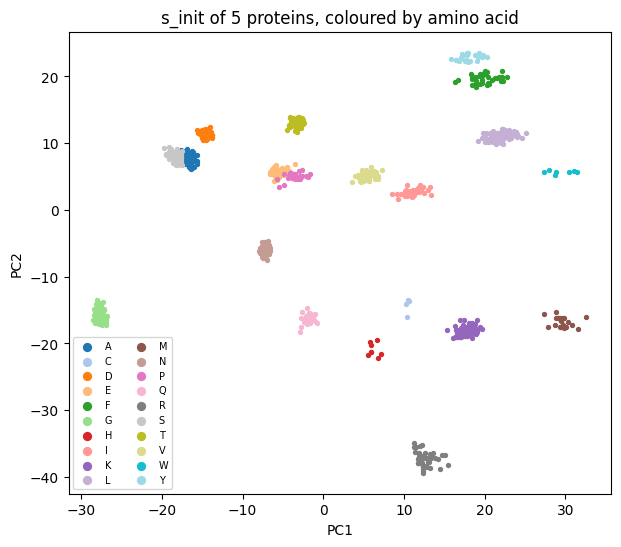

In [15]:
import matplotlib.pyplot as plt

data = {acc: torch.load(EMB_DIR / f"{acc}_seed42.pt", weights_only=False) for acc in PROTEINS}
for acc in PROTEINS:
    assert tokens(data[acc]["s_init"]).shape[0] == len(data[acc]["sequence"]), acc
letters = "".join(data[acc]["sequence"] for acc in PROTEINS)
X_init = np.vstack([tokens(data[acc]["s_init"]) for acc in PROTEINS])
X_trunk = np.vstack([tokens(data[acc]["si_trunk"]) for acc in PROTEINS])
agreement = {"s_init": residue_type_agreement(X_init, letters),
             "si_trunk": residue_type_agreement(X_trunk, letters)}
print("nearest residue has the same amino acid:", {k: round(v, 3) for k, v in agreement.items()})

# PCA of s_init, coloured by amino acid
centred = X_init - X_init.mean(0)
_, _, vt = np.linalg.svd(centred, full_matrices=False)
pc = centred @ vt[:2].T
aa = sorted(set(letters))
fig, ax = plt.subplots(figsize=(7, 6))
for k, a in enumerate(aa):
    m = np.array(list(letters)) == a
    ax.scatter(pc[m, 0], pc[m, 1], s=8, color=plt.cm.tab20(k % 20), label=a)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("s_init of 5 proteins, coloured by amino acid")
ax.legend(ncol=2, fontsize=7, markerscale=2)
fig.savefig(WORK / "s_init_pca_by_residue.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
rows = []
for acc in PROTEINS:
    ca = ca_coordinates(f"out_proteins/{acc}/seed_42/{acc}_seed_42_sample_1_model.cif")
    rows.append({"protein": acc,
                 "rho_s_init": round(similarity_vs_distance(tokens(data[acc]["s_init"]), ca), 3),
                 "rho_si_trunk": round(similarity_vs_distance(tokens(data[acc]["si_trunk"]), ca), 3)})
space_table = pd.DataFrame(rows)
space_table

,protein,rho_s_init,rho_si_trunk
0,P0AA25,0.084,0.597
1,P12301,-0.006,0.387
2,P21796,-0.005,0.464
3,P0DP23,0.006,0.498
4,P62799,0.004,0.270


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The structures here are the MSA-free predictions of this run (their quality does not matter for this
question: it asks whether each representation knows which residues are close in *its own* prediction).

## 10. Summary numbers

In [17]:
import json

path = WORK / "summary_of3_input_embeddings.json"
if "n_model" in globals():  # the whole notebook ran in this session
    summary = {
        "openfold3_version": md.version("openfold3"),
        "torch_version": torch.__version__,
        "gpu": torch.cuda.get_device_name(0),
        "checkpoint": CKPT.name,
        "checkpoint_sha256": sha256(str(CKPT)),
        "checkpoint_format": ckpt_format,
        "model_numbers": n_model,
        "input_embedder_tensors": len(sub),
        "input_embedder_numbers": n_sub,
        "input_embedder_share_percent": round(100 * n_sub / n_model, 3),
        "strict_load": True,
        "max_diff_vs_full_model_gpu": max(diff_gpu.values()),
        "max_diff_vs_full_model_cpu": max(diff_cpu.values()),
        "fragment_cpu_ms": round(1000 * t_cpu, 1),
        "seeds": spread,
        "proteins": proteins_table.to_dict(orient="records"),
        "residue_type_agreement": agreement,
        "similarity_vs_distance": space_table.to_dict(orient="records"),
    }
else:  # resumed at §7: keep the numbers of the first run, add the model-free ones
    summary = json.loads(path.read_text())
summary["model_free"] = {
    "fragment_feature_seconds": round(seconds_features, 1),
    "feature_tensors": n_tensors,
    "differing_tensors_vs_full_pipeline_same_state": differ_after_42,
    "differing_tensors_vs_first_query_of_run": differ_first,
    "max_diff_vs_full_model_same_features": max(diff_free.values()),
    "reproducible_with_seed": reproducible,
    "other_seed_changes_conformers": other_seed_differs,
    "proteins": modelfree_table.to_dict(orient="records"),
}
path.write_text(json.dumps(summary, indent=2, default=float))
print(json.dumps(summary, indent=2, default=float))

{
  "openfold3_version": "0.4.3",
  "torch_version": "2.11.0+cu130",
  "gpu": "Tesla T4",
  "checkpoint": "of3-p2-155k.pt",
  "checkpoint_sha256": "af09eac4f29cef856633af07558cb143226fe95ebbef2c20921769d4a5f4bee4",
  "checkpoint_format": "plain parameter file",
  "model_numbers": 571537240,
  "input_embedder_tensors": 98,
  "input_embedder_numbers": 1345568,
  "input_embedder_share_percent": 0.235,
  "strict_load": true,
  "max_diff_vs_full_model_gpu": 0.0,
  "max_diff_vs_full_model_cpu": 3.0517578125e-05,
  "fragment_cpu_ms": 71.1,
  "seeds": {
    "s_input": {
      "n_seeds": 5,
      "same_residue_cosine_between_seeds": 0.9995571374893188,
      "relative_difference_between_seeds": 0.0321744279935956,
      "different_residues_cosine": 0.9251131415367126
    },
    "s_init": {
      "n_seeds": 5,
      "same_residue_cosine_between_seeds": 0.9999575614929199,
      "relative_difference_between_seeds": 0.012556584272533654,
      "different_residues_cosine": 0.9704514741897583
    },

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 11. What this establishes

* **Extraction.** OpenFold3 0.4.3 runs on Colab; its input embedding is `InputEmbedderAllAtom`
  (1.35 M numbers, 0.24 % of the checkpoint); those weights alone load strictly into the module (a 5 MB
  file); the module alone reproduces the trained model's output on the same input (§5); and with
  OpenFold3's data pipeline run on its own (§7–§8) the extraction needs neither the rest of the model,
  nor the checkpoint, nor a GPU — 1–2 s per protein on a CPU.
* **OpenFold3 seeds after it builds the features.** The reference conformers are random, and OpenFold3
  sets the seed only at the start of each prediction step: the first query of a run is not
  reproducible, and every later query draws its conformers from the state the previous query's seed
  left. The input embedding changes by about 1–3 % between seeds. Fixing the random state before
  featurization, one chain per query, makes the embedding a deterministic function of sequence and seed —
  the embedding the full model computes from the same features.
* **What the representations contain.** `s_init` identifies the residue type (the nearest
  neighbour of every residue is the same amino acid) but carries no spatial information (correlation
  with distance ≈ 0); the trunk representation `si_trunk` does (ρ ≈ 0.3–0.6). The input embedding is a
  learned, sequence-level description of each residue; structure appears only after the Pairformer.
* **Next.** Input embeddings for every protein of the set cost minutes on a CPU. What to analyse with
  them — for example as an input space for the information-imbalance analysis (notebook 05) — is
  open.

Save `summary_of3_input_embeddings.json`, `s_init_pca_by_residue.png` and this notebook into the
repository (`notebooks/06_openfold3_input_embeddings.ipynb`; the json and png into `results/`). The
embeddings stay on Drive (large; `data/` is not in git).